# Trabajo Semanal 3 - Aproximación Chebyshev
<img src="./img/logo_UTN.svg" align="right" width="150" />

*Alumno: Contreras Juan Manuel*  
*Materia: Teoría de Circuitos II*  
*Institución: UTN FRBA*  
*Profesores: Mariano Llamedo Soria, David Moharos*

---

## 1. Obtener la transferencia mediante aproximación de Chebyshev

### Datos de la plantilla de requerimientos:
<img src="./img/consigna.png" width="1000">  

* $\alpha_{max} = 0,5 \text{ dB}$ (Atenuación máxima en banda de paso)
* $\alpha_{min} = 30 \text{ dB}$ (Atenuación mínima en banda de espurio)
* $f_p = 40 \text{ kHz}$ (Frecuencia de paso)
* $f_s = 10 \text{ kHz}$ (Frecuencia de stop)

### Normalización y conversión al Prototipo Pasabajo (LP)
Normalizamos respecto a la frecuencia angular de la banda de paso ($\omega_p$):
$$\omega_p = 2\pi \cdot f_p = 2\pi \cdot 40\text{ kHz}$$
$$\omega_s = 2\pi \cdot f_s = 2\pi \cdot 10\text{ kHz}$$

La frecuencia normalizada del pasa altos (HP) resulta:
$$\Omega_{p,HP} = \omega_p$$
$$\Omega_{s,HP} = \frac{\omega_s}{\omega_p} = \frac{10\text{ kHz}}{40\text{ kHz}} = 0,25$$

Aplicamos la transformación de frecuencias para obtener el **prototipo pasabajo equivalente** ($\Omega_{LP} = \frac{1}{\Omega_{HP}}$):
$$\Omega_{s,LP} = \frac{1}{\Omega_{s,HP}} = \frac{1}{0,25} = 4$$

### Determinación del ripple y del orden ($n$) mediante iteración

$$\epsilon^2 = 10^{\frac{\alpha_{max}}{10}} - 1 \approx 0,122$$

Evaluamos la atenuación  $\alpha(\Omega_{s,LP})$ incrementando el orden $n$  hasta alcanzar la condición $\alpha(4) \geq \alpha_{min} = 30 \text{ dB}$:

* **Para $n = 1$:** $$C_1(4) = \cosh(1 \cdot \cosh^{-1}(4)) = 4$$  
  $$\alpha(4) = 10 \log_{10}\left(1 + 0,122 \cdot 4^2\right) = 10 \log_{10}(2,952) \approx 4,7 \text{ dB} \quad (\text{No cumple})$$

* **Para $n = 2$:** $$C_2(4) = \cosh(2 \cdot \cosh^{-1}(4)) = 2 \cdot 4^2 - 1 = 31$$  
  $$\alpha(4) = 10 \log_{10}\left(1 + 0,122 \cdot 31^2\right) = 10 \log_{10}(118,24) \approx 20,72 \text{ dB} \quad (\text{No cumple})$$

* **Para $n = 3$:** $$C_3(4) = \cosh(3 \cdot \cosh^{-1}(4)) = 4 \cdot 4^3 - 3 \cdot 4 = 244$$  
  $$\alpha(4) = 10 \log_{10}\left(1 + 0,122 \cdot 244^2\right) = 10 \log_{10}(7264,1) \approx 38,61 \text{ dB} \quad (\text{Cumple!})$$

Por lo tanto, adoptamos un **orden $n = 3$**.

Para hallar analíticamente de dónde provienen las raíces del sistema, planteamos la función de la magnitud al cuadrado de la transferencia reemplazando con el polinomio de Chebyshev de tercer orden $C_3(\omega) = 4\omega^3 - 3\omega$:

$$|T(\omega)|^2 = \frac{1}{1 + \epsilon^2 C_n^2} = \frac{1}{1 + 0,122 \cdot (4\omega^3 - 3\omega)^2} = \frac{1}{1 + 1,952\omega^6 - 2,928\omega^4 + 1,098\omega^2}$$

Extendiendo la función al plano complejo $s$ mediante la sustitución de variables $\omega = \frac{s}{j}$ (donde $\omega^2 = -s^2$, $\omega^4 = s^4$ y $\omega^6 = -s^6$):

$$|T(s)|^2 = \left. |T(\omega)|^2 \right|_{\omega = \frac{s}{j}} = \frac{1}{-1,952s^6 - 2,928s^4 - 1,098s^2 + 1}$$

Las raíces de este denominador de grado $2n = 6$ definirán las singularidades totales del filtro.

### Ubicación de polos del prototipo Pasabajo ($T_{LP}(p)$)
Buscamos las raíces del denominador obtenido en el paso anterior resolviendo la ecuación:

$$-1,952s^6 - 2,928s^4 - 1,098s^2 + 1 = 0$$

In [31]:
import numpy as np

# Definimos los coeficientes del denominador de |T(s)|^2
coeficientes_den = [-1.952, 0, -2.928, 0, -1.098, 0, 1]

# Calculamos las 6 raíces complejas de la ecuación
todas_las_raices = np.roots(coeficientes_den)

print("Raices del polinomio de orden 6")
for i, raiz in enumerate(todas_las_raices, 1):
    print(f"Raíz {i}: {raiz:.4f}")

Raices del polinomio de orden 6
Raíz 1: -0.3132+1.0219j
Raíz 2: -0.3132-1.0219j
Raíz 3: 0.3132+1.0219j
Raíz 4: 0.3132-1.0219j
Raíz 5: -0.6265+0.0000j
Raíz 6: 0.6265+0.0000j


Evaluando los **polos** para $k = 1, 2, 3, 4, 5, 6$:
* $p_{1,2} = -0,3133 \pm j1,0220$
* $p_3 = -0,6267$
* $p_{4,5} = 0,3133 \pm j1,0220$
* $p_6 = 0,6267$

Para garantizar la **estabilidad** del sistema, descartamos las raíces con parte real positiva y nos quedamos únicamente con los polos ubicados en el semiplano izquierdo:

* $p_{1} = -0,6267$
* $p_{2,3} = -0,3133 \pm j1,0220$

### Transformación al Filtro Pasaaltos y factorización en FOS y SOS
Aplicamos la transformación para convertir el prototipo LP a HP objetivo mediante la sustitución de: $p = \frac{1}{s}$.  
Reemplazando los valores numéricos de los polos del:

$$T_{HP}(s) = \frac{1}{\left(\frac{1}{s} + 0,6267\right)} \cdot \frac{1}{\left(\frac{1}{s} + 0,3133 - j1,0220\right)\left(\frac{1}{s} + 0,3133 + j1,0220\right)}$$

Multiplicando por $s$ en la primera sección y por $s^2$ en la segunda para normalizar la estructura de los polinomios en el numerador, la función de transferencia final queda expresada como el producto ordenado de una **Sección de Primer Orden (FOS)** y una **Sección de Segundo Orden (SOS)**:

$$T_{HP}(s) = T_{FOS}(s) \cdot T_{SOS}(s)$$

$$T_{HP}(s) = \left[ \frac{s}{s + 1,5957} \right] \cdot \left[ \frac{s^2}{s^2 + 0,5484s + 0,8751} \right]$$

Donde se interpreta que:
* La **FOS** aporta un cero en el origen y un polo real en $\sigma = -1,5957$.
* La **SOS** aporta un cero doble en el origen y un par de polos complejos conjugados con $\omega_0 = \sqrt{0,8751} \approx 0,9354$ y $Q = \frac{\omega_0}{0,5484} \approx 1,7057$.
---

## 2. Análisis Cualitativo de la Respuesta en Frecuencia y Comparación de Mapas de Polos y Ceros

### Comparación de los Mapas de Polos y Ceros ($pzmap$)

La transformación de frecuencias utilizada para pasar del prototipo pasabajo ($p$) al filtro pasaaltos definitivo ($s$) es:
$$p = \frac{1}{s}$$

Esta inversión compleja genera un mapeo geométrico drástico en las singularidades del plano complejo:

1. **Mapeo de los Ceros:** El prototipo pasabajo de Chebyshev Tipo I posee todos sus ceros (en este caso, 3) en el infinito.
   * Al aplicar la transformación, esos ceros se trasladan de forma directa al **origen ($s = 0$)**. Por lo tanto, el filtro pasa altos presenta un **cero triple en el origen**.

2. **Mapeo de los Polos:**
   * La inversión geométrica afecta tanto al módulo como al ángulo de los polos del semiplano izquierdo. 
   * Si un polo del prototipo $p = |p| e^{j\theta}$, en el plano del pasa altos se ubicará en $\frac{1}{|p|} e^{-j\theta}$.

A continuación, se observa la comparación cualitativa de ambos planos complejos:

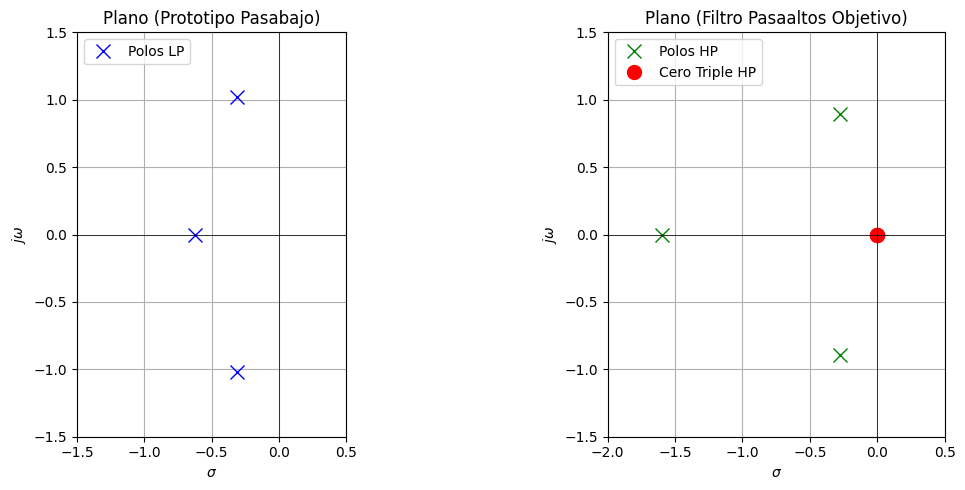

In [9]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt

# Retomamos los polinomios del prototipo pasabajo
den_lp = [1, 1.2534, 1.5353, 0.7157]
num_lp = [0.7157]

# Obtenemos los polinomios del pasaaltos factorizado
den_hp = [1, 2.1441, 1.7503, 1.3964]
num_hp = [1, 0, 0, 0] # s^3

# Raíces
polos_lp = np.roots(den_lp)
ceros_lp = np.roots(num_lp)

polos_hp = np.roots(den_hp)
ceros_hp = np.roots(num_hp)

# Gráfico comparativo de Mapas de Polos y Ceros
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plano (Prototipo Pasa bajo)
ax1.plot(np.real(polos_lp), np.imag(polos_lp), 'bx', markersize=10, label='Polos LP')
ax1.axhline(0, color='black', lw=0.5)
ax1.axvline(0, color='black', lw=0.5)
ax1.set_title('Plano (Prototipo Pasabajo)')
ax1.set_xlabel(r'$\sigma$')
ax1.set_ylabel(r'$j\omega$')
ax1.grid(True)
ax1.set_aspect('equal', adjustable='box')
ax1.set_xlim([-1.5, 0.5])
ax1.set_ylim([-1.5, 1.5])
ax1.legend()

# Plano (Filtro Pasa altos)
ax2.plot(np.real(polos_hp), np.imag(polos_hp), 'gx', markersize=10, label='Polos HP')
ax2.plot(np.real(ceros_hp), np.imag(ceros_hp), 'ro', markersize=10, label='Cero Triple HP')
ax2.axhline(0, color='black', lw=0.5)
ax2.axvline(0, color='black', lw=0.5)
ax2.set_title('Plano (Filtro Pasaaltos Objetivo)')
ax2.set_xlabel(r'$\sigma$')
ax2.set_ylabel(r'$j\omega$')
ax2.grid(True)
ax2.set_aspect('equal', adjustable='box')
ax2.set_xlim([-2, 0.5])
ax2.set_ylim([-1.5, 1.5])
ax2.legend()

plt.tight_layout()
plt.show()

### Comportamiento Cualitativo de la Respuesta en Frecuencia

#### 1. Respuesta de Módulo $|T_{HP}(j\omega)|$
* **Frecuencias de Cero ($\omega \to 0$):** Debido a la presencia del cero triple en el origen ($s^3$ en el numerador), la ganancia en continua y bajas frecuencias es nula ($0$ veces, o $-\infty \text{ dB}$). En las cercanías del origen, el filtro atenúa con una pendiente muy abrupta de **$+60 \text{ dB/década}$** ($+20 \text{ dB/década}$ por cada cero).
* **Zona de Transición y Banda de Paso ($\omega \approx \Omega_p = 1$):** Al acercarse a la frecuencia de corte normalizada, los polos complejos de la SOS introducen un "sobrepico" que compensa la caída. Al ser una aproximación de Chebyshev, el módulo ingresa a la banda de paso exhibiendo el rizado característico (oscilando entre $0 \text{ dB}$ y $-0,5 \text{ dB}$ un total de 3 veces, coincidente con el orden $n=3$).
* **Altas Frecuencias ($\omega \to \infty$):** Al evaluar la transferencia normalizada cuando $s \to \infty$:
  $$\lim_{s \to \infty} \frac{s^3}{s^3 + \dots} = 1 \implies 0 \text{ dB}$$

#### 2. Respuesta de Fase $\arg(T_{HP}(j\omega))$
* **En bajas frecuencias ($\omega \to 0$):** El cero triple en el origen aporta una fase constante y positiva de $+270^\circ$ ($3 \times 90^\circ$).
* **A frecuencias intermedias:** A medida que la frecuencia aumenta, los polos del SPI empiezan a aportar retraso de fase (fase negativa). El polo real (FOS) aportará $-45^\circ$ en su propia frecuencia de quiebre, y el par conjugado (SOS) aportará un salto de fase más abrupto alrededor de su $\omega_0$ debido a su $Q > 0,707$.
* **En altas frecuencias ($\omega \to \infty$):** Cada uno de los 3 polos habrá aportado un total de $-90^\circ$ de retraso de fase ($-270^\circ$ en total). Por lo tanto, la fase asintótica final converge exactamente a $270^\circ - 270^\circ = 0^\circ$.

#### 3. Comparativa entre $|T_{HP}(j\omega)|$ y $|T_{LP}(j\omega)|$

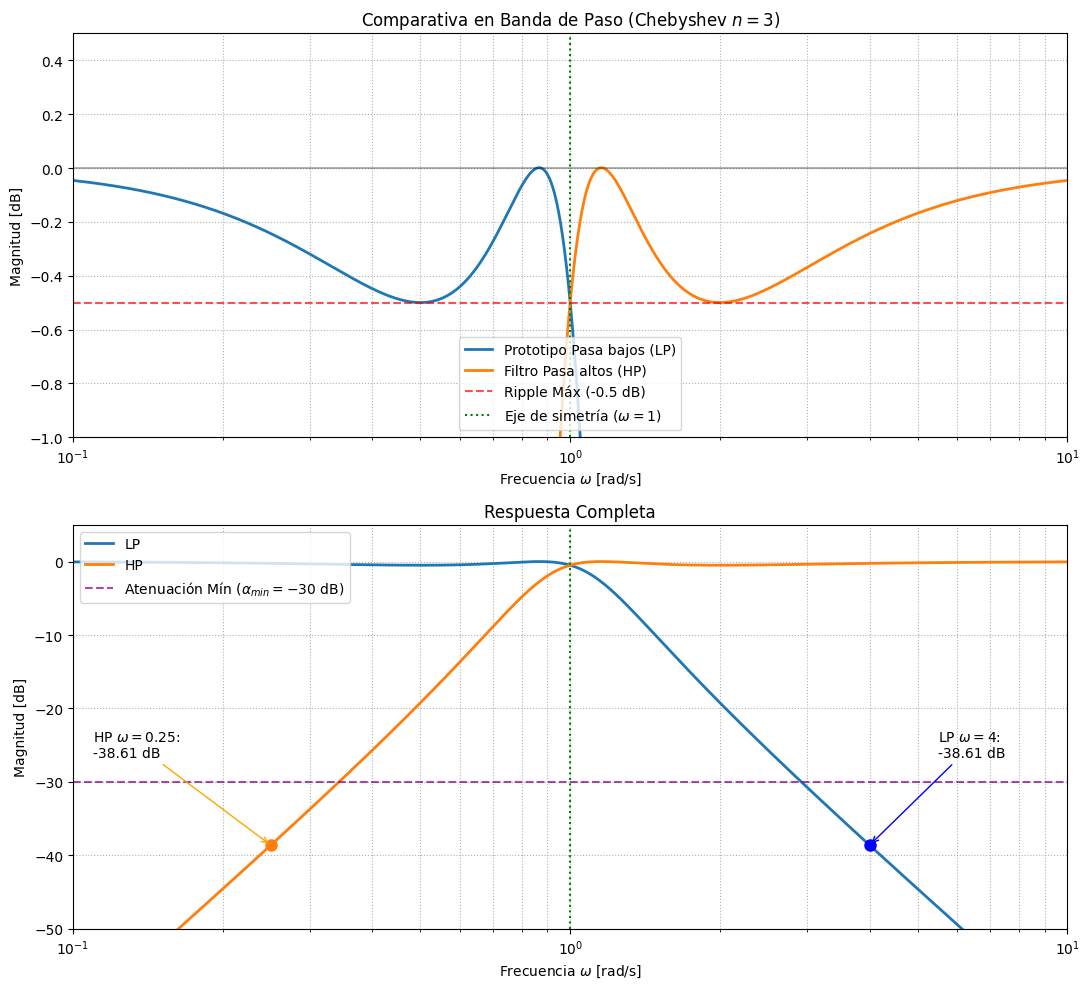

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. PARAMETRIZACIÓN DEL PROTOTIPO PASA BAJOS
p_lp = np.array([-0.3132 + 1.0219j, -0.3132 - 1.0219j, -0.6265])
z_lp = np.array([])
k_lp = np.abs(np.prod(p_lp))


# 2. TRANSFORMACIÓN AL FILTRO PASA ALTOS
p_hp = 1 / p_lp
z_hp = np.array([0, 0, 0])
k_hp = 1.0


# 3. VECTOR DE FRECUENCIAS PARA RESPUESTAS EN FRECUENCIA
w_log = np.logspace(-1, 1, 2000) 

# Cálculo de las respuestas en frecuencia
_, h_lp = signal.freqs_zpk(z_lp, p_lp, k_lp, worN=w_log)
mag_lp_db = 20 * np.log10(np.abs(h_lp))

# Respuesta HP
_, h_hp = signal.freqs_zpk(z_hp, p_hp, k_hp, worN=w_log)
mag_hp_db = 20 * np.log10(np.abs(h_hp))

# Puntos específicos de atenuación en las bandas de stop
_, h_lp_4 = signal.freqs_zpk(z_lp, p_lp, k_lp, worN=[4.0])
mag_lp_4_db = 20 * np.log10(np.abs(h_lp_4[0]))

_, h_hp_025 = signal.freqs_zpk(z_hp, p_hp, k_hp, worN=[0.25])
mag_hp_025_db = 20 * np.log10(np.abs(h_hp_025[0]))


# 4. GRÁFICOS COMPARATIVOS ESPEJADOS
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10))

# GRÁFICO 1: DETALLE DE BANDA DE PASO
ax1.semilogx(w_log, mag_lp_db, label='Prototipo Pasa bajos (LP)', color='tab:blue', linewidth=2)
ax1.semilogx(w_log, mag_hp_db, label='Filtro Pasa altos (HP)', color='tab:orange', linewidth=2)

# Líneas de referencia de la banda de paso
ax1.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax1.axhline(y=-0.5, color='red', linestyle='--', alpha=0.7, label='Ripple Máx (-0.5 dB)')
ax1.axvline(x=1, color='green', linestyle=':', linewidth=1.5, label=r'Eje de simetría ($\omega = 1$)')

ax1.set_xlim([0.1, 10])
ax1.set_ylim([-1, 0.5])
ax1.set_title('Comparativa en Banda de Paso (Chebyshev $n=3$)')
ax1.set_xlabel(r'Frecuencia $\omega$ [rad/s]')
ax1.set_ylabel(r'Magnitud [dB]')
ax1.grid(True, which='both', linestyle=':')
ax1.legend(loc='lower center')

# GRÁFICO 2: VISTA COMPLETA Y BANDAS DE ATENUACIÓN
ax2.semilogx(w_log, mag_lp_db, label='LP', color='tab:blue', linewidth=2)
ax2.semilogx(w_log, mag_hp_db, label='HP', color='tab:orange', linewidth=2)

# Líneas de cota límite de atenuación y simetría
ax2.axhline(y=-30, color='purple', linestyle='--', alpha=0.7, label='Atenuación Mín ($\\alpha_{min} = -30$ dB)')
ax2.axvline(x=1, color='green', linestyle=':', linewidth=1.5)

# Resaltar punto LP (w = 4)
ax2.plot(4.0, mag_lp_4_db, 'bo', markersize=8)
ax2.annotate(r'LP $\omega =4$:' + f'\n{mag_lp_4_db:.2f} dB', 
             xy=(4.0, mag_lp_4_db), 
             xytext=(5.5, mag_lp_4_db + 12),
             arrowprops=dict(arrowstyle="->", color='blue'))

# Resaltar punto HP (w = 0.25)
ax2.plot(0.25, mag_hp_025_db, 'o', color='tab:orange', markersize=8)
ax2.annotate(r'HP $\omega =0.25$:'+f'\n{mag_hp_025_db:.2f} dB', 
             xy=(0.25, mag_hp_025_db), 
             xytext=(0.11, mag_hp_025_db + 12),
             arrowprops=dict(arrowstyle="->", color='orange'))

# Ajustes de límites y visualización limpios
ax2.set_xlim([0.1, 10])
ax2.set_ylim([-50, 5])
ax2.set_title('Respuesta Completa')
ax2.set_xlabel(r'Frecuencia $\omega$ [rad/s]')
ax2.set_ylabel('Magnitud [dB]')
ax2.grid(True, which='both', linestyle=':')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

* **Efecto espejo en escala logarítmica:** Al usar la transformación $s \to 1/s$, la gráfica del HP es un reflejo exacto de la del LP con eje de simetría en $\omega = 1\text{ rad/s}$.
* **Inversión de bandas:** Todo lo que pasa en el LP a una frecuencia $\omega$, ocurre en el HP a la frecuencia inversa $1/\omega$. El ripple de la banda de paso del LP ($0 < \omega < 1$) se pasa idéntico a la banda de paso del HP ($\omega > 1$), y la caída del LP hacia altas frecuencias se convierte en la rampa de atenuación del HP hacia bajas frecuencias.
* **Simetría en los puntos de interés:** Como se ve en el segundo gráfico, la atenuación se mantiene exacta en las frecuencias inversas:
  * El LP a $\omega = 4\text{ rad/s}$ atenúa **$-38.61\text{ dB}$**.
  * El HP a la frecuencia inversa $\omega = 0.25\text{ rad/s}$ alcanza **exactamente los mismos $-38.61\text{ dB}$**, cumpliendo con los $-30\text{ dB}$ mínimos requeridos por la plantilla.
---

## 3. Implementación del Circuito Normalizado Pasivo con Separadores Activos

Para realizar el diseño, adoptamos la estrategia de síntesis mediante la descomposición en bloques de baja complejidad (FOS y SOS) conectados por un buffer.


### Etapa 1: Sección de Primer Orden (FOS Pasa altos)

<img src="./img/circuito1.jpg" width="400">  

* **Función de transferencia circuital:**
  $$T_{FOS}(s) = \frac{s}{s + \frac{1}{R_1 \cdot C_1}}$$

* **Igualando con nuestra transferencia normalizada:**
  $$\frac{1}{R_1 \cdot C_1} = 1,5957 \text{ rad/s}$$

* **Cálculo de componentes normalizados:**
  Adoptando como norma de componente un valor de capacidad unitario:
  $$C_1 = 1 \text{ F} \implies R_1 = \frac{1}{1,5957} \approx 0,6267 \ \Omega$$


### Etapa 2: Segunda Sección de Orden (SOS Pasa altos RLC)

<img src="./img/circuito2.jpg" width="400">  

* **Función de transferencia circuital:**
  Aplicando divisor de tensión en el dominio de Laplace:
  $$T_{SOS}(s) = \frac{V_{out}(s)}{V_{in}(s)} = \frac{sL}{R_2 + \frac{1}{sC_2} + sL} = \frac{s^2L}{s^2L + sR_2 + \frac{1}{C_2}}$$
  
  Dividiendo numerador y denominador por $L$ para llevarlo a la forma mónica:
  $$T_{SOS}(s) = \frac{s^2}{s^2 + s \cdot \frac{R_2}{L} + \frac{1}{L \cdot C_2}}$$

* **Igualando coeficientes con nuestra SOS analítica:**
  $$T_{SOS}(s) = \frac{s^2}{s^2 + 0,5484s + 0,8751}$$

  1. Para el término independiente del denominador ($\omega_0^2$):
     $$\frac{1}{L \cdot C_2} = 0,8751$$
  2. Para el término lineal en $s$ ($\frac{\omega_0}{Q}$):
     $$\frac{R_2}{L} = 0,5484$$

* **Cálculo de componentes normalizados:**
  Adoptamos un valor de capacidad unitario para la norma del capacitor de esta etapa:
  $$C_2 = 1 \text{ F}$$

  Despejando el valor del inductor normalizado $L$:
  $$L = \frac{1}{0,8751 \cdot C_2} = \frac{1}{0,8751 \cdot 1} \approx 1,1427 \text{ H}$$

  Despejando el valor del resistor serie normalizado $R_2$:
  $$R_2 = 0,5484 \cdot L = 0,5484 \cdot 1,1427 \approx 0,6267 \ \Omega$$

### Resumen del Circuito Normalizado RLC
<img src="./img/circuito3.jpg" width="700">  

---

## 4. Activación del Inductor mediante GIC de Antoniou

Para la estructura SOS pasiva RLC en configuración de paso alto, el inductor normalizado $L = 1,1427 \text{ H}$ está **aterrizado**. Esto nos permite implementar un **GIC de Antoniou** para simular esta Inductancia.

### Análisis de la configuración del GIC

<img src="./img/circuito4.jpg" width="300">  

$$Z_{in}(s) = \frac{Y_1 \cdot Y_3 \cdot Y_5}{Y_2 \cdot Y_4}$$

Para simular una **inductancia pura** ($Z_{in}(s) = sL_{eq}$), se selecciona  al elemento capacitivo en la admitancia $Y_4$:

* $Y_1 = G_1 = \frac{1}{R_1}$
* $Y_2 = G_2 = \frac{1}{R_2}$
* $Y_3 = G_3 = \frac{1}{R_3}$
* $Y_4 = sC$
* $Y_5 = G_5 = \frac{1}{R_5}$

Reemplazando estas admitancias en la ecuación de $Z_{in}(s)$:

$$Z_{in}(s) = \frac{\frac{1}{R_1} \cdot \frac{1}{R_3} \cdot \frac{1}{R_5}}{\frac{1}{R_2} \cdot sC} = s \cdot \left( \frac{R_1 \cdot R_3 \cdot R_5 \cdot C}{R_2} \right)$$

Por lo tanto, la inductancia equivalente simulada resulta:

$$L_{eq} = \frac{R_1 \cdot R_3 \cdot R_5 \cdot C}{R_2}$$

### Determinación de componentes componentes normalizados

De acuerdo a los requerimientos de diseño establecidos, se adopta una estrategia donde todas las resistencias del circuito toman un valor unitario ($R = 1 \ \Omega$).

$$R_1 = R_2 = R_3 = R_5 = 1 \ \Omega$$

Bajo esta condición, la fórmula de la inductancia equivalente se simplifica de la siguiente manera:

$$L_{eq} = \frac{1 \cdot 1 \cdot 1 \cdot C}{1} \implies L_{eq} = C$$

Dado que el inductor normalizado de nuestra SOS es $L = 1,1427 \text{ H}$, los componentes del GIC quedan definidos con los siguientes valores normalizados:

* $R_1 = 1 \ \Omega$
* $R_2 = 1 \ \Omega$
* $R_3= 1 \ \Omega$
* $R_5 = 1 \ \Omega$
* $C = 1,1427 \text{ F}$

<img src="./img/circuito5.jpg" width="300">  

### Resumen del Circuito Normalizado

<img src="./img/circuito6.jpg" width="500">  

---

## 5. Implementación de la SOS mediante Estructura Activa MFB Pasa Altos y Estudio de Sensibilidad

Como alternativa al circuito RLC, implementamos la sección de segundo orden (SOS) utilizando una topología activa de **Realimentación Múltiple (MFB)** en configuración pasa altos.

### Análisis Circuital de la Topología MFB Pasa Altos

<img src="./img/circuito7.jpg" width="600">  

A partir del análisis de nodos para esta estructura activa, la función de transferencia está determinada por la siguiente expresión:

$$T(s) = \frac{-s^2 \frac{C_3}{C_1}}{s^2 + s \cdot \frac{C_1 + C_2 + C_3}{R_2 C_1 C_2} + \frac{1}{R_1 R_2 C_1 C_2}}$$

Para simplificar el diseño analítico, adoptamos la condición de **capacitores unitarios e iguales**:

$$C_1 = C_2 = C_3 = 1 \text{ F}$$

Sustituyendo estos valores en la transferencia, la expresión se simplifica a:

$$T(s) = \frac{-s^2}{s^2 + s \cdot \frac{3}{R_2} + \frac{1}{R_1 R_2}}$$

### Determinación de Componentes Normalizados

Igualamos los parámetros de la transferencia circuital con los valores de nuestra SOS analítica ($T_{SOS}(s) = \frac{s^2}{s^2 + 0,5484s + 0,8751}$):

1. **Frecuencia angular propia ($\omega_0^2$):**
   $$\omega_0^2 = \frac{1}{R_1 R_2} = 0,8751 \implies \omega_0 \approx 0,9354 \text{ rad/s}$$

2. **Término lineal ($\frac{\omega_0}{Q}$):**
   $$\frac{\omega_0}{Q} = \frac{3}{R_2} = 0,5484$$

Despejamos el valor de la resistencia de realimentación $R_2$:

$$R_2 = \frac{3}{0,5484} \approx 5,4705 \ \Omega$$

Utilizando el valor de $R_2$, despejamos la resistencia de entrada $R_1$ a partir del término independiente:

$$R_1 = \frac{1}{0,8751 \cdot R_2} = \frac{1}{0,8751 \cdot 5,4705} \approx 0,2089 \ \Omega$$

Por lo tanto, el conjunto de componentes normalizados para la SOS MFB queda definido por:
* $C_1 = C_2 = C_3 = 1 \text{ F}$
* $R_1 = 0,2089 \ \Omega$
* $R_2 = 5,4705 \ \Omega$

<img src="./img/circuito8.jpg" width="600"> 

### Estudio de Sensibilidad

Definimos la sensibilidad de un parámetro $A$ respecto a las variaciones de un componente pasivo $x$ mediante la ecuación:

$$S_x^A = \frac{\partial A}{\partial x} \cdot \frac{x}{A} = \frac{\partial \ln(A)}{\partial \ln(x)}$$

A partir de la función de transferencia, parametrizamos las ecuaciones del circuito para componentes genéricos:

$$\omega_0 = \left( R_1 R_2 C_1 C_2 \right)^{-1/2}$$

$$Q = \frac{\omega_0}{\frac{C_1 + C_2 + C_3}{R_2 C_1 C_2}} = \frac{\left( R_1 R_2 C_1 C_2 \right)^{-1/2}}{\frac{C_1 + C_2 + C_3}{R_2 C_1 C_2}} = \frac{\sqrt{R_2}}{\sqrt{R_1}} \cdot \frac{\sqrt{C_1 C_2}}{C_1 + C_2 + C_3}$$

#### 1. Sensibilidad de la frecuencia de corte respecto a $C_1$ ($S_{\omega_0}^{C_1}$)

Expresamos $\omega_0$ aislando la variable $C_1$:
$$\omega_0 = (R_1 R_2 C_2)^{-1/2} \cdot C_1^{-1/2}$$

Aplicando el operador de sensibilidad:
$$S_{\omega_0}^{C_1} = \frac{\partial \ln(\omega_0)}{\partial \ln(C_1)} = -\frac{1}{2}$$

$$S_{\omega_0}^{C_1} = -0,5$$

#### 2. Sensibilidad del factor de calidad respecto a $R_1$ ($S_Q^{R_1}$)

Aislamos la variable $R_1$ en la expresión de $Q$, agrupando el resto como una constante $K$:
$$Q = R_1^{-1/2} \cdot K$$

Aplicando la definición:
$$S_Q^{R_1} = \frac{\partial (R_1^{-1/2} \cdot K)}{\partial R_1} \cdot \frac{R_1}{R_1^{-1/2} \cdot K} = \left(-\frac{1}{2} R_1^{-3/2} \cdot K\right) \cdot \frac{R_1}{R_1^{-1/2} \cdot K} = -\frac{1}{2}$$

$$S_Q^{R_1} = -0,5$$

#### 3. Sensibilidad del factor de calidad respecto a $R_2$ ($S_Q^{R_2}$)

Aislamos la variable $R_2$ en la expresión de $Q$, agrupando el resto como una constante $K$:
$$Q = R_2^{1/2} \cdot K$$

Aplicando la definición:
$$S_Q^{R_2} = \frac{\partial (R_2^{1/2} \cdot K)}{\partial R_2} \cdot \frac{R_2}{R_2^{1/2} \cdot K} = \left(\frac{1}{2} R_2^{-1/2} \cdot K\right) \cdot \frac{R_2}{R_2^{1/2} \cdot K} = \frac{1}{2}$$

$$S_Q^{R_2} = 0,5$$

---

## 6. Simulación Circuital en LTspice y Verificación de los Modelos mediante Cursores

Para validar el comportamiento de las estructuras analizadas, se implementaron tres configuraciones circuitales independientes en LTspice. La simulación se realizó desnormalizando exclusivamente en frecuencia mediante la directiva `.param w0 = 2*pi*40k`, lo que desplaza el eje de simetría del filtro a la frecuencia de la banda de paso real ($f_p = 40 \text{ kHz}$). 

El análisis se ejecutó mediante un barrido de CA (`.ac dec 1000 1k 100k`) para verificar con precisión el cumplimiento de la plantilla de requerimientos mediante el uso de cursores.

### Descripción de los Circuitos Simulados

<img src="./img/spice1.png" width="600">  

<img src="./img/spice2.png" width="600">  

<img src="./img/spice3.png" width="600">  

* **Circuito 1 (Pasivo RLC):** Estructura de referencia compuesta por una FOS pasiva pasa altos ($C_1$, $R_1$) y una SOS pasiva RLC ($C_2$, $R_2$, $L_1$). El valor del inductor se parametrizó como `{1.1423/w0}` para corregir el escalamiento en frecuencia.
* **Circuito 2 (Activación por GIC):** Se reemplaza la bobina del Circuito 1 por el GIC de Antoniou manteniendo las condiciones de diseño fijadas: resistencias equivalentes de $1 \ \Omega$ ($R_5$, $R_6$, $R_7$, $R_8$) y el valor de la inductancia transferido al componente reactivo interno $C_5 = \{1.1423/w0\}$.
* **Circuito 3 (Topología Activa MFB):** Alternativa que reemplaza la SOS pasiva por una etapa MFB ($C_7, C_8, C_9, R_{10}, R_{11}$).


### Verificación de la Plantilla con Cursores de Simulación

Al analizar las respuestas en frecuencia de los tres nodos de salida (`Vo1`, `Vo2` y `Vo3`), las curvas de módulo resultan superpuestas, demostrando la equivalencia exacta de las tres topologías. La medición con cursores arroja los siguientes resultados:

<img src="./img/spice4.png" width="1500">  

#### 1. Banda de Paso ($f_p = 40 \text{ kHz}$)
* **Cursor en Módulo:** Al posicionar el cursor en $40 \text{ kHz}$, se registra una atenuación exacta de **$-0,5 \text{ dB}$** en los tres circuitos. 
* **Verificación:** Esto corresponde al límite inferior del ripple de Chebyshev ($\alpha_{max}$), confirmando que la banda de paso finaliza exactamente en la frecuencia de la plantilla.

#### 2. Banda de Atenuación ($f_s = 10 \text{ kHz}$)
* **Cursor en Módulo:** Al trasladar el cursor a la banda de stop en $10 \text{ kHz}$ (frecuencia cuatro veces menor que la de corte, equivalente a $\Omega_{s,LP} = 4$), los tres filtros registran un nivel de señal de **$-38,61 \text{ dB}$**.
* **Verificación:** Como el requerimiento mínimo de la plantilla exigía una atenuación superior a los $\alpha_{min} = 30 \text{ dB}$, se comprueba mediante simulación que el diseño de orden $n=3$ cumple holgadamente con las condiciones de selectividad impuestas.

#### 3. Comportamiento Asintótico ($f \to 1 \text{ kHz}$)
* **Medición de Pendiente:** Al medir la diferencia de ganancia entre las décadas bajas de la zona de stop, el trazado de los cursores confirma una pendiente de caída de **$+60 \text{ dB/década}$** ($+20 \text{ dB/década}$ por cada uno de los tres ceros en el origen), validando el orden total del sistema.

---

## 7. Comparación con Aproximación de Máxima Planicidad (Butterworth)

### 1. Análisis Conceptual: ¿Se podría implementar una red del mismo orden ($n=3$)?

La respuesta corta es **no, no se cumpliría con la plantilla de requerimientos**. 

La aproximación de Chebyshev distribuye el error permitiendo un *ripple* en la banda de paso a cambio de obtener una zona de transición muchísimo más abrupta. Por el contrario, la aproximación de Butterworth (máxima planicidad) es monótona y sacrifica selectividad en pos de una respuesta perfectamente plana en la banda de paso.

Si mantuviéramos el mismo orden ($n = 3$) pero cambiáramos a Butterworth, la atenuación en la banda de stop caería drásticamente por debajo de los $30 \text{ dB}$ exigidos.

Para demostrarlo analíticamente, recordamos los datos del prototipo pasabajo equivalente en la banda de stop:
* $\Omega_{s,LP} = 4$
* $\alpha_{max} = 0,5 \text{ dB} \implies \epsilon^2 \approx 0,122$

La ecuación de atenuación para un filtro Butterworth pasabajo de orden $n$ es:

$$\alpha(\Omega) = 10 \log_{10}\left(1 + \epsilon^2 \cdot \Omega^{2n}\right)$$

Evaluando para el orden idéntico $n = 3$ en la frecuencia de stop $\Omega_{s,LP} = 4$:

$$\alpha(4) = 10 \log_{10}\left(1 + 0,122 \cdot 4^{2 \cdot 3}\right) = 10 \log_{10}\left(1 + 0,122 \cdot 4096\right)$$
$$\alpha(4) = 10 \log_{10}\left(1 + 499,71\right) = 10 \log_{10}(500,71) \approx 26,99 \text{ dB}$$

Como se observa, $\alpha(4) \approx 27 \text{ dB} < 30 \text{ dB}$. Por lo tanto, un filtro Butterworth de orden $n=3$ **no cumple con la plantilla**. Para lograrlo con máxima planicidad, estaríamos obligados a incrementar el orden del sistema a $n=4$.

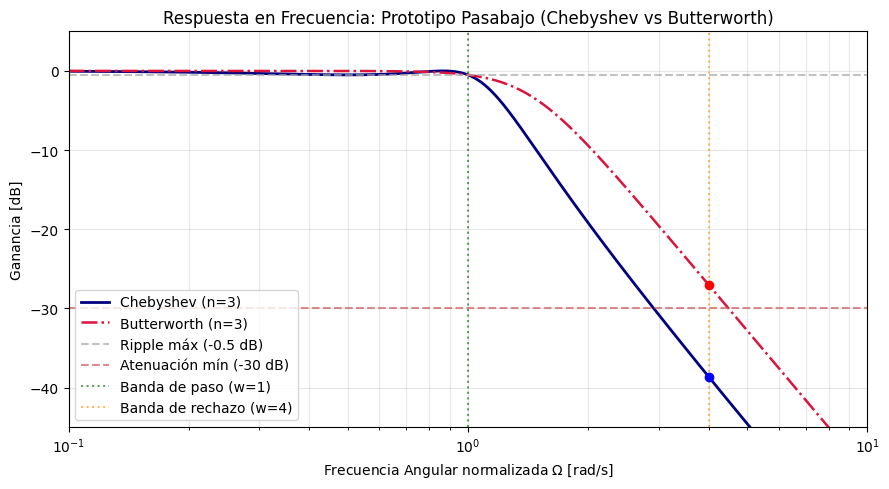

In [13]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt

# Configuración del filtro
atenuacion_max_pass = 0.5  # alpha_max
w_stop = 4.0               # Frecuencia de corte de banda de rechazo

# 1. Cálculo de Chebyshev Tipo I (n=3)
# Conseguimos ceros, polos y ganancia, y pasamos directo a función de transferencia
z_c, p_c, k_c = sig.cheb1ap(N=3, rp=atenuacion_max_pass)
num_cheb, den_cheb = sig.zpk2tf(z_c, p_c, k_c)

# 2. Cálculo de Butterworth normalizado y reescalado
z_b, p_b, k_b = sig.butter(3, 1.0, analog=True, output='zpk')

# Ajuste de los polos de Butterworth para que caiga justo -0.5 dB en w=1
factor_escala = (10**(atenuacion_max_pass / 10) - 1)**(-1/6)  # Simplificado de (eps**(-1/3))
p_butt_ok = p_b * factor_escala
k_butt_ok = np.abs(np.prod(p_butt_ok))
num_butt, den_butt = sig.zpk2tf(z_b, p_butt_ok, k_butt_ok)

# 3. Evaluación en frecuencia
frecuencias = np.logspace(-1, 1, 1000)
_, r_cheb = sig.freqs(num_cheb, den_cheb, worN=frecuencias)
_, r_butt = sig.freqs(num_butt, den_butt, worN=frecuencias)

# Cálculo exacto en w = 4 para el print y los puntos del gráfico
_, evaluar_cheb = sig.freqs(num_cheb, den_cheb, worN=[w_stop])
_, evaluar_butt = sig.freqs(num_butt, den_butt, worN=[w_stop])

db_cheb_w4 = -20 * np.log10(np.abs(evaluar_cheb[0]))
db_butt_w4 = -20 * np.log10(np.abs(evaluar_butt[0]))


# Gráfico comparativo ---
plt.figure(figsize=(9, 5))

# Curvas principales en dB
plt.semilogx(frecuencias, 20 * np.log10(np.abs(r_cheb)), label='Chebyshev (n=3)', color='navy', lw=2)
plt.semilogx(frecuencias, 20 * np.log10(np.abs(r_butt)), label='Butterworth (n=3)', color='crimson', linestyle='-.', lw=1.8)

# Marcadores de las especificaciones
plt.axhline(-0.5, color='darkgray', linestyle='--', alpha=0.7, label='Ripple máx (-0.5 dB)')
plt.axhline(-30, color='indianred', linestyle='--', alpha=0.7, label='Atenuación mín (-30 dB)')
plt.axvline(1.0, color='darkgreen', linestyle=':', alpha=0.6, label='Banda de paso (w=1)')
plt.axvline(w_stop, color='darkorange', linestyle=':', alpha=0.6, label='Banda de rechazo (w=4)')

# Destacar los puntos evaluados
plt.scatter([w_stop], [-db_cheb_w4], color='blue', zorder=5)
plt.scatter([w_stop], [-db_butt_w4], color='red', zorder=5)

plt.title('Respuesta en Frecuencia: Prototipo Pasabajo (Chebyshev vs Butterworth)')
plt.xlabel(r'Frecuencia Angular normalizada $\Omega$ [rad/s]')
plt.ylabel('Ganancia [dB]')
plt.xlim([0.1, 10])
plt.ylim([-45, 5])
plt.grid(True, which='both', alpha=0.3)
plt.legend(loc='lower left')
plt.tight_layout()

plt.show()

---